# Lane Detection using Classical Computer Vision (OpenCV)
AI Mini Project - Provisional/Draft notebook.

**Dataset:** Udacity CarND Lane Lines sample set (6 images + 3 videos) from https://github.com/udacity/CarND-LaneLines-P1  
**Pipeline:** Grayscale → Gaussian blur → Canny → ROI mask → Hough → slope-based averaging → overlay (+ temporal smoothing for video)

In [1]:
import subprocess, os
if not os.path.exists('data/udacity'):
    subprocess.run(['git','clone','--depth','1','https://github.com/udacity/CarND-LaneLines-P1.git','data/udacity'])
import cv2, glob, numpy as np, pandas as pd, matplotlib.pyplot as plt
from lane_detection import detect, PARAMS
print(PARAMS)

{'blur_k': 5, 'canny_lo': 50, 'canny_hi': 150, 'rho': 2, 'theta': 0.017453292519943295, 'hough_thresh': 20, 'min_len': 20, 'max_gap': 100, 'min_abs_slope': 0.45}


## 1. Basic data analysis

In [2]:
ds = pd.read_csv('results/dataset_summary.csv') if os.path.exists('results/dataset_summary.csv') else None
ds

,name,type,width,height,frames,mean_brightness,contrast_std
0,solidWhiteCurve.jpg,image,960,540,1,131.2,41.7
1,solidWhiteRight.jpg,image,960,540,1,130.1,43.8
2,solidYellowCurve.jpg,image,960,540,1,129.1,34.0
3,solidYellowCurve2.jpg,image,960,540,1,134.7,33.3
4,solidYellowLeft.jpg,image,960,540,1,130.4,35.0
5,whiteCarLaneSwitch.jpg,image,960,540,1,135.5,31.9
6,challenge.mp4,video,1280,720,251,112.2,47.7
7,solidWhiteRight.mp4,video,960,540,221,124.7,44.4
8,solidYellowLeft.mp4,video,960,540,681,128.3,34.5


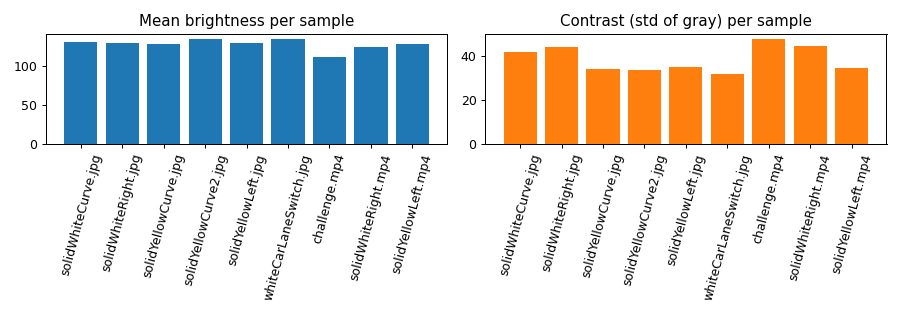

In [3]:
from IPython.display import Image
Image('results/dataset_analysis.png')

## 2. Pipeline stages on one image

{'n_segments': 17, 'left': (np.float64(-0.7376510770317383), np.float64(662.7775049356053)), 'right': (np.float64(0.608391628918546), np.float64(20.461598054523215)), 'left_x': 166, 'right_x': 853, 'both': True}


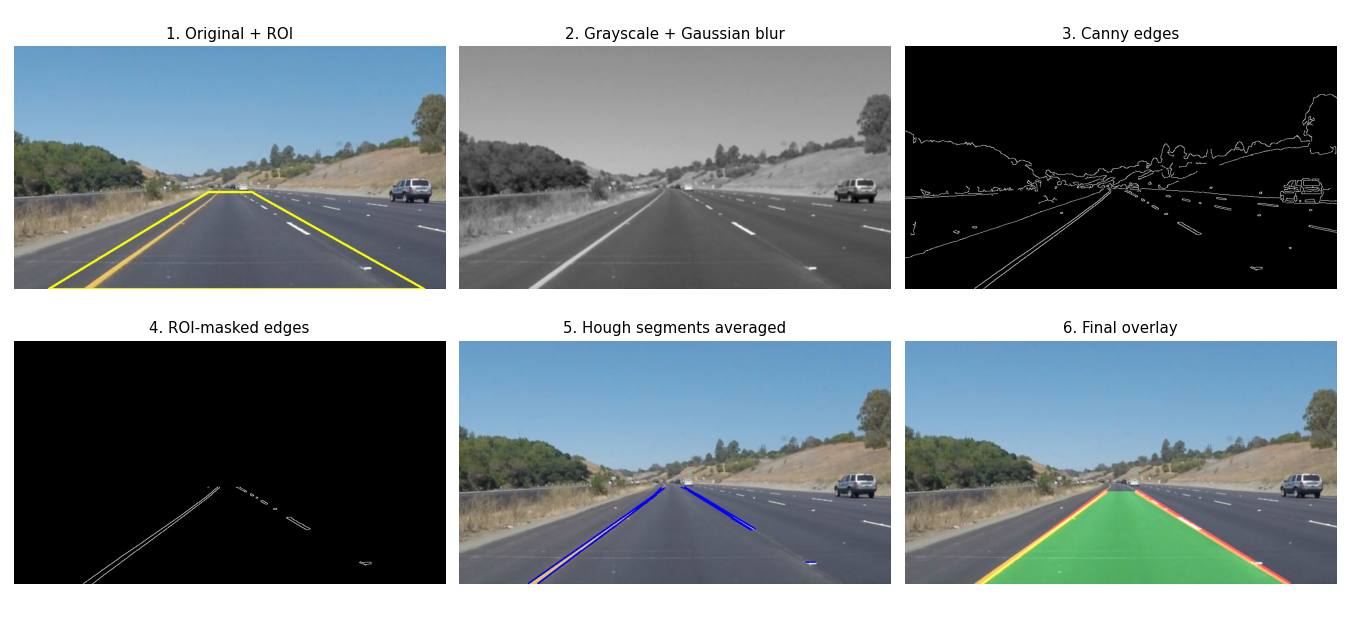

In [4]:
im = cv2.imread('data/udacity/test_images/solidYellowCurve.jpg')
out, st, info = detect(im)
print(info)
Image('results/pipeline_stages.png')

## 3. Results on all sample images

In [5]:
res = []
for f in sorted(glob.glob('data/udacity/test_images/*.jpg')):
    o, _, i = detect(cv2.imread(f))
    res.append(dict(image=os.path.basename(f), segments=i['n_segments'], both_lanes=i['both']))
pd.DataFrame(res)

,image,segments,both_lanes
0,solidWhiteCurve.jpg,16,True
1,solidWhiteRight.jpg,16,True
2,solidYellowCurve.jpg,17,True
3,solidYellowCurve2.jpg,25,True
4,solidYellowLeft.jpg,16,True
5,whiteCarLaneSwitch.jpg,19,True


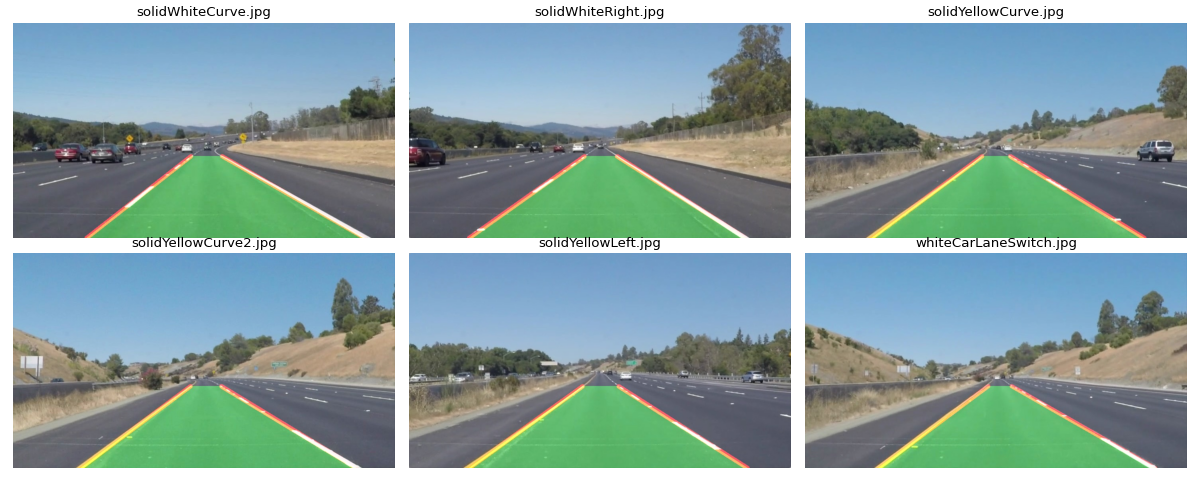

In [6]:
Image('results/all_image_outputs.png')

## 4. Video results (detection rate, jitter, FPS), raw vs temporally smoothed
*Jitter = mean frame-to-frame change (pixels) of the lane position at the bottom of the image; lower = more stable.*

In [7]:
pd.read_csv('results/video_results.csv')

,video,mode,frames,both_lanes_pct,jitter_px,fps
0,challenge.mp4,raw,251,98.8,27.67,36.5
1,challenge.mp4,smoothed,251,98.8,6.60,36.9
2,solidWhiteRight.mp4,raw,221,100.0,4.34,82.5
3,solidWhiteRight.mp4,smoothed,221,100.0,0.90,83.7
4,solidYellowLeft.mp4,raw,681,100.0,5.29,84.2
5,solidYellowLeft.mp4,smoothed,681,100.0,0.98,81.0


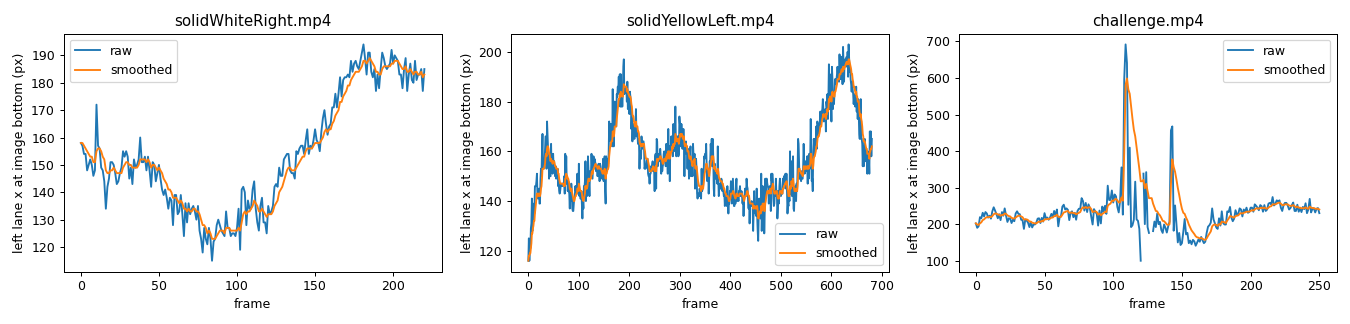

In [8]:
Image('results/stability_plot.png')

## 5. Known limitation (honest failure case)
On `challenge.mp4` both lanes are *detected* in ~99% of frames, but the left line is sometimes pulled onto the shadowed road edge instead of the yellow marking. No ground-truth labels are available in this sample set, so detection rate is **not** accuracy. Next step: evaluate on TuSimple with labels.

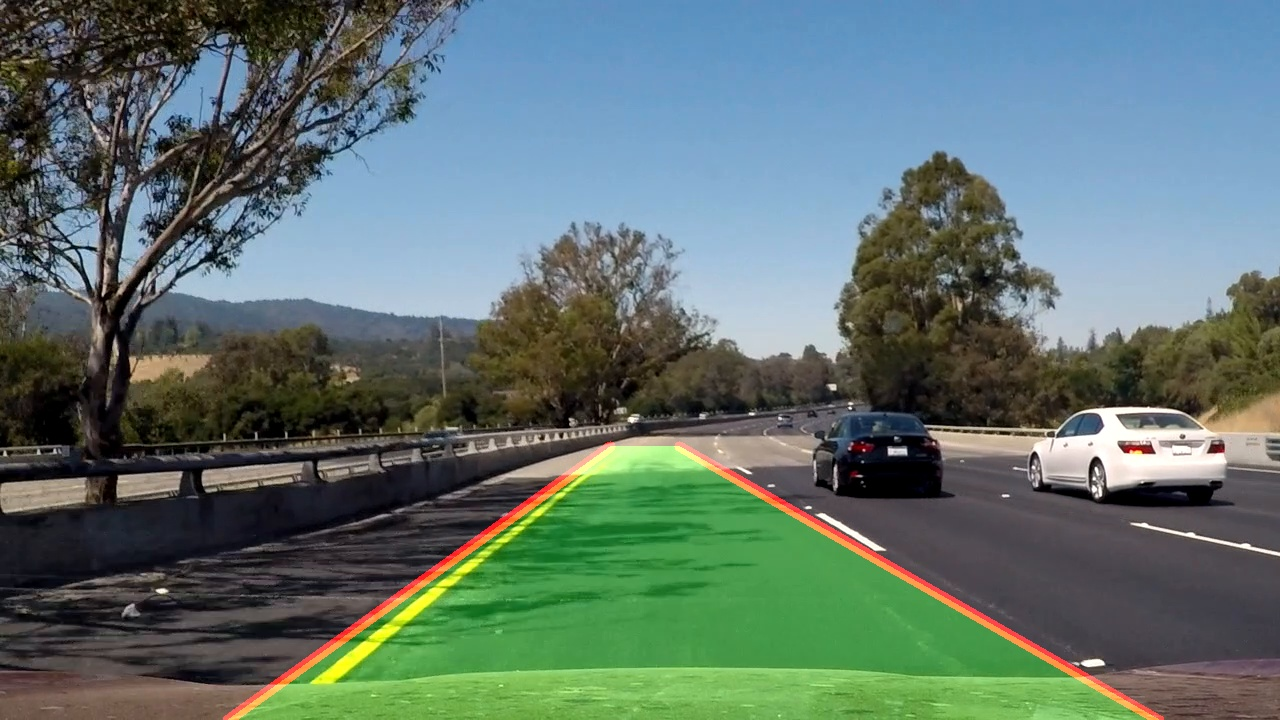

In [9]:
Image('results/frame_challenge_90.jpg')